In [2]:
# ═══════════════════════════════════════════
#  ЗАПУСТИ ОДИН РАЗ
# ═══════════════════════════════════════════
from pathlib import Path
from math import ceil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from PIL import Image
%matplotlib inline

repo_root = Path.cwd()
if not (repo_root / 'data' / 'final_dataset').exists():
    repo_root = repo_root.parent.parent

IMG_DIR = repo_root / 'data' / 'final_dataset' / 'images'
LBL_DIR = repo_root / 'data' / 'final_dataset' / 'labels'
FLAG_FILE = repo_root / 'runs' / 'label_review' / 'flagged_review_all.txt'
FLAG_FILE.parent.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'HM','LQS','QHS','MS','A1_SU-35','A2_C-130','A3_C-17','A4_C-5','A5_F-16',
    'A6_TU-160','A7_E-3','A8_B-52','A9_P-3C','A10_B-1B','A11_E-8','A12_TU-22',
    'A13_F-15','A14_KC-135','A15_F-22','A16_FA-18','A17_TU-95','A18_KC-10',
    'A19_SU-34','A20_SU-24','FSC',
]
COLORS = plt.colormaps['tab20'].resampled(len(CLASS_NAMES))

def read_yolo(lbl_path):
    boxes = []
    if not lbl_path.exists():
        return boxes
    for ln, line in enumerate(lbl_path.read_text().splitlines(), 1):
        parts = line.split()
        if len(parts) == 5:
            boxes.append((ln, int(parts[0]), *map(float, parts[1:])))
    return boxes

# Все изображения, отсортированные по имени
all_images = sorted(IMG_DIR.glob('*.jpg')) + sorted(IMG_DIR.glob('*.png'))
all_images = sorted(set(all_images), key=lambda p: p.name)
print(f'Всего изображений: {len(all_images)}')
print(f'Нумерация: 1 – {len(all_images)}')

Всего изображений: 9648
Нумерация: 1 – 9648


Страница 20 | #20–#20 из 9648


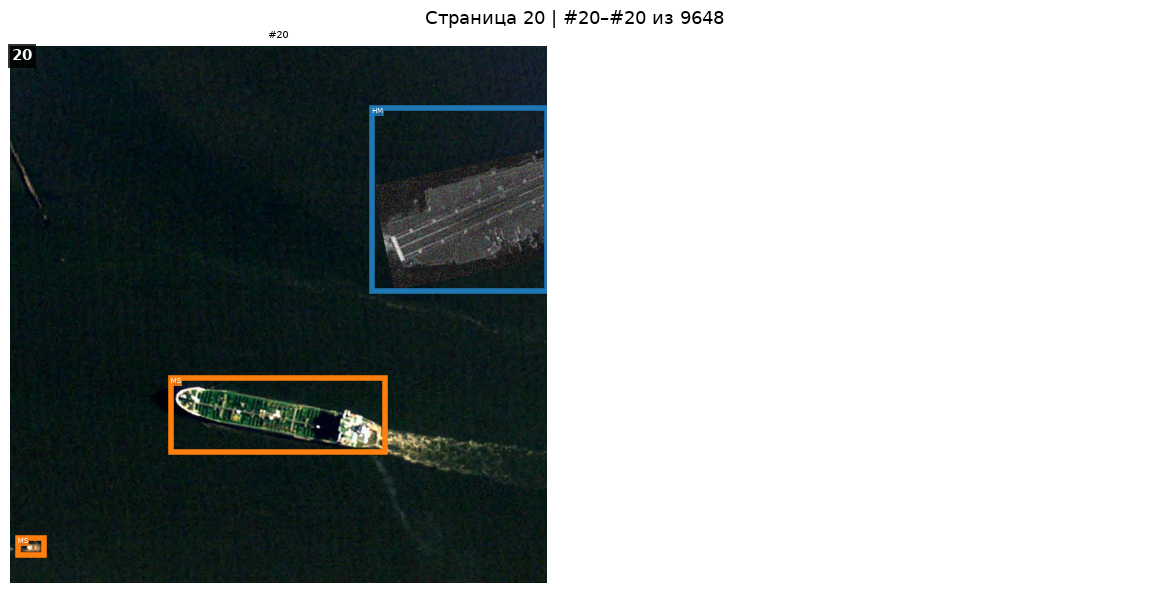

In [9]:
# ═══════════════════════════════════════════
#  МЕНЯЙ ТОЛЬКО PAGE
#  PAGE=1 → #1–50,  PAGE=2 → #51–100 ...
# ═══════════════════════════════════════════
PAGE       = 20
BATCH_SIZE = 1
COLS       = 2

plt.close('all')
_start = (PAGE - 1) * BATCH_SIZE
_end   = min(_start + BATCH_SIZE, len(all_images))
_batch = list(range(_start, _end))
print(f'Страница {PAGE} | #{_start+1}–#{_end} из {len(all_images)}')

_rows = ceil(len(_batch) / COLS)
fig, axes = plt.subplots(_rows, COLS, figsize=(COLS * 6, _rows * 6))
axes = list(np.array(axes).flat)

for ax, idx in zip(axes, _batch):
    img_path = all_images[idx]
    lbl_path = LBL_DIR / (img_path.stem + '.txt')
    num = idx + 1

    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)

    for ln, cls, cx, cy, bw, bh in read_yolo(lbl_path):
        x1, y1 = (cx - bw/2)*W, (cy - bh/2)*H
        color = COLORS(cls)
        ax.add_patch(Rectangle((x1, y1), bw*W, bh*H,
                                fill=False, edgecolor=color, linewidth=4))
        ax.text(max(0,x1), max(0,y1), CLASS_NAMES[cls], color='white',
                fontsize=5, va='top',
                bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor='none'))

    ax.text(3, 3, f'{num}', color='white', fontsize=11, fontweight='bold', va='top',
            bbox=dict(facecolor='black', alpha=0.8, pad=3, edgecolor='none'))
    ax.set_title(f'#{num}', fontsize=7)
    ax.axis('off')

for ax in axes[len(_batch):]:
    ax.axis('off')

plt.suptitle(f'Страница {PAGE} | #{_start+1}–#{_end} из {len(all_images)}', fontsize=13)
plt.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
# ═══════════════════════════════════════════
#  ФЛАГИ — пишешь только номера
#  Накапливаются между сессиями
# ═══════════════════════════════════════════
new_flags = [
    107,
    135,
    158,
    344,
    454,
    465,
    489,
    516,
    537,
    547,
    564,
    567,
    576,
    580,
    587,
    591,
    592,
    610,
    612,
    634,
    685,
    688,
    689,
    692,
    695,
    699,
    700,
    703,
    738,
    752,
    766,
    770,
    771,
    772,
    773,
    775,
    790,
    791,
    794,
    795,
    796,
    800,
    803,
    813,
    823,
    824,
    839,
    847,
    874,
    909,
    917,
    920,
    921,
    922,
    931,
    934,
    954,
    969,
    985,
    988,
    1007,
    1011,
    1013,
    1014,
    1018,
    1019,
    1020,
    1024,
    1026,
    1028,
    1035,
    1040,
    1041,
    1079,
    1080,
    1097,
    1100,
    1108,
    1112,
    1114,
    1117,
    1132,
    1136,
    1141,
    1159,
    1160,
    1168,
    1177,
    1178,
    1182,
    1183,
    1184,
    1186,
    1187,
    1189,
    1191,
    1192,
    1201,
    1202,
    1203,
    1204,
    1205,
    1208,
    1210,
    1211,
    1217,
    1235,
    1241,
    1242,
    1267,
    1270,
    1272,
    1273,
    1279,
    1280,
    1284,
    1286,
    1288,
    1299,
    1309,
    1321,
    1324,
    1329,
    1346,
    1378,
    1396,
    1402,
    1425,
    1429,
    1432,
    1437,
    1438,
    1482,
    1513,
    1515,
    1516,
    1518,
    1668,
    2228,
    2285,
    2372,
    2540,
    2648,
    2655,
    2656,
    3107,
    3108,
    3120,
    3122,
    3156,
    3164,
    3244,
    3261,
    3378,
    3679,
    3696,
    3699,
    3723,
    3726,
    3926,
    3927,
    3936,
    3948,
    3949,
    3950,
    3951,
    3952,
    3955,
    3956,
    3957,
    3961,
    3962,
    4020,
    4029,
    4030,
    4032,
    4049,
    4052,
    4054,
    4057,
    4083,
    5622,
    5647,
    5908,
    6191,
    6192,
    6194,
    6200,
    6204,
    6210,
    6212,
    6214,
    6216,
    6224,
    6225,
    6229,
    6230,
    6233,
    6234,
    6237,
    6240,
    6244,
    6251,
    6255,
    6262,
    6264,
    6270,
    6283,
    6299,
    6309,
    6310,
    6327,
    6328,
    6330,
    6337,
    7174,
    9095,
    9552,
    9559,
    9560,
    9572,
    9573,
    9579,
    9619
]

saved = set()
if FLAG_FILE.exists():
    saved = {l.strip() for l in FLAG_FILE.read_text().splitlines() if l.strip()}

for n in new_flags:
    idx = n - 1
    if 0 <= idx < len(all_images):
        stem = all_images[idx].stem
        saved.add(stem)
        print(f'  ✓ {n} → {stem}')
    else:
        print(f'  ✗ {n} — нет такого номера')

FLAG_FILE.write_text('\n'.join(sorted(saved)))
print(f'\nВсего помечено: {len(saved)}')

  ✓ 107 → 000686_bmp.rf.3711b416beed7595e3f3a4872b9449fa
  ✓ 135 → 000870_bmp.rf.ec1f86a770f734b8ab360b4f5a534999
  ✓ 158 → 001129_bmp.rf.9a342c0a9a7a767f1466543561b8b16b
  ✓ 344 → 003077_bmp.rf.898e6f4fd355af660d310f44f376a816
  ✓ 454 → 004191_bmp.rf.8801332bc99530b5253daea6209f7b47
  ✓ 465 → 004237_bmp.rf.54c0cf9adcd72a4a1e512d00caa9c224
  ✓ 489 → 004337_bmp.rf.97788d4ccd11d9cd1277a5c42e8a461b
  ✓ 516 → 004477_bmp.rf.a5cbf62e251277e8f8d1a1cf231d4b91
  ✓ 537 → 004538_bmp.rf.3daad0e54117fb0c8faf2264954f922a
  ✓ 547 → 004601_bmp.rf.f91b1332aea113b31920e92338cda979
  ✓ 564 → 004665_bmp.rf.512d910f5e3b7205d820036a650786e7
  ✓ 567 → 004676_bmp.rf.979e126b391b078607347a64c6cc8c90
  ✓ 576 → 004715_bmp.rf.8cbecd2498e98ad46b1ffff0d9aabea9
  ✓ 580 → 004729_bmp.rf.14a3f9d0c707b2b407134985c54aed40
  ✓ 587 → 01-PAN-20240420-113-325-L00000010882-CCD3_5_crop6
  ✓ 591 → 01-PAN-20240420-113-325-L00000010882-CCD3_6_crop1
  ✓ 592 → 01-PAN-20240420-113-325-L00000010882-CCD3_6_crop2
  ✓ 610 → 01-PAN-20240

In [10]:
# ═══════════════════════════════════════════
#  УДАЛЕНИЕ ПОМЕЧЕННЫХ ИЗОБРАЖЕНИЙ И ЛЕЙБЛОВ
#  Запусти после проверки списка флагов
# ═══════════════════════════════════════════
if not FLAG_FILE.exists():
    print('Файл флагов не найден.')
else:
    stems = {l.strip() for l in FLAG_FILE.read_text().splitlines() if l.strip()}
    print(f'Помечено к удалению: {len(stems)} файлов\n')

    deleted_img, deleted_lbl, missing = 0, 0, []

    for stem in sorted(stems):
        img_deleted = False
        for ext in ('.jpg', '.png'):
            img_path = IMG_DIR / (stem + ext)
            if img_path.exists():
                img_path.unlink()
                deleted_img += 1
                img_deleted = True
                break

        lbl_path = LBL_DIR / (stem + '.txt')
        if lbl_path.exists():
            lbl_path.unlink()
            deleted_lbl += 1

        if not img_deleted:
            missing.append(stem)

    print(f'Удалено изображений: {deleted_img}')
    print(f'Удалено лейблов:     {deleted_lbl}')
    if missing:
        print(f'\nНе найдены изображения ({len(missing)}):')
        for s in missing:
            print(f'  ✗ {s}')


Помечено к удалению: 216 файлов

Удалено изображений: 216
Удалено лейблов:     216
